# Step 1: Data Exploration

**Goal:** Understand the NYC taxi demand dataset and build intuition for *why* an LSTM autoencoder is the right tool for anomaly detection here.

The dataset comes from the [Numenta Anomaly Benchmark (NAB)](https://github.com/numenta/NAB). It contains the number of NYC taxi passengers aggregated into 30-minute intervals from **July 1, 2014** to **January 31, 2015** -- roughly 7 months and ~10,300 records.

Five known anomaly windows correspond to real-world events:
1. **NYC Marathon** (Nov 1-3)
2. **Thanksgiving** (Nov 25-29)
3. **Christmas** (Dec 23-27)
4. **New Year's** (Dec 29 - Jan 3)
5. **Winter Blizzard** (Jan 24-29)

In [1]:
%matplotlib inline

import sys
from pathlib import Path

# Find project root (works whether jupyter is started from code/, project root, or elsewhere)
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "code":
    PROJECT_ROOT = PROJECT_ROOT.parent
# Verify we found the right directory
assert (PROJECT_ROOT / "pyproject.toml").exists(), (
    f"Could not find project root. CWD={Path.cwd()}\n"
    "Please run: uv run jupyter notebook   (from the project root)"
)
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (14, 4)
plt.rcParams["figure.dpi"] = 100

print(f"Project root: {PROJECT_ROOT}")
print(f"Python: {sys.version.split()[0]}")

Project root: /Users/jonpaino/Documents/Striim/lstm-autoencoder-spark-kafka
Python: 3.11.14


## 1. Load Data

We use the project's `src.preprocess` module, which provides:
- `load_data()` -- reads the CSV and parses timestamps
- `ANOMALY_WINDOWS` -- the 5 known anomaly periods
- `SAMPLES_PER_DAY` (48) and `SAMPLES_PER_WEEK` (336) -- the periodicity constants

In [2]:
import logging
# Suppress verbose logging from src modules
for name in ["src.preprocess", "src.model", "src.scorer", "src.synthetic"]:
    logging.getLogger(name).setLevel(logging.WARNING)

from src.preprocess import load_data, ANOMALY_WINDOWS, SAMPLES_PER_DAY, SAMPLES_PER_WEEK

df = load_data(str(PROJECT_ROOT / "data" / "nyc_taxi.csv"))

print(f"Shape: {df.shape}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"Sampling interval: 30 minutes")
print(f"Samples per day: {SAMPLES_PER_DAY}")
print(f"Samples per week: {SAMPLES_PER_WEEK}")
df.head()

Shape: (10320, 2)
Date range: 2014-07-01 00:00:00 to 2015-01-31 23:30:00
Sampling interval: 30 minutes
Samples per day: 48
Samples per week: 336


,timestamp,value
0,2014-07-01 00:00:00,10844
1,2014-07-01 00:30:00,8127
2,2014-07-01 01:00:00,6210
3,2014-07-01 01:30:00,4656
4,2014-07-01 02:00:00,3820


## 2. Full Time Series with Anomaly Windows

Let's plot the entire time series and shade the 5 known anomaly windows. This gives a bird's-eye view of the data and where the anomalies fall.

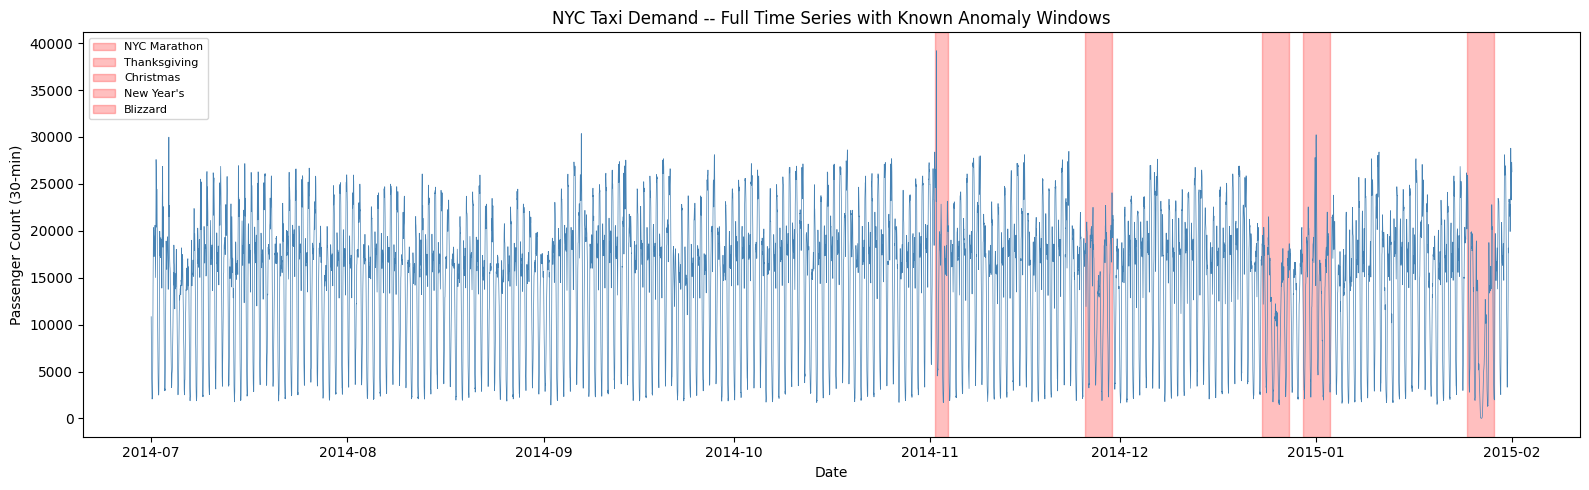

In [3]:
anomaly_labels = ["NYC Marathon", "Thanksgiving", "Christmas", "New Year's", "Blizzard"]

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df["timestamp"], df["value"], linewidth=0.5, color="steelblue")

for i, (start, end) in enumerate(ANOMALY_WINDOWS):
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.25, color="red",
               label=anomaly_labels[i])

ax.set_title("NYC Taxi Demand -- Full Time Series with Known Anomaly Windows")
ax.set_xlabel("Date")
ax.set_ylabel("Passenger Count (30-min)")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

## 3. Periodicity Analysis

Taxi demand is inherently periodic. People commute on weekdays, go out on weekends, and sleep at night -- every single week. This regularity is what makes the data suitable for an autoencoder: we can **learn** the normal weekly pattern and then detect deviations.

Let's overlay several weeks to see how consistent the pattern is.

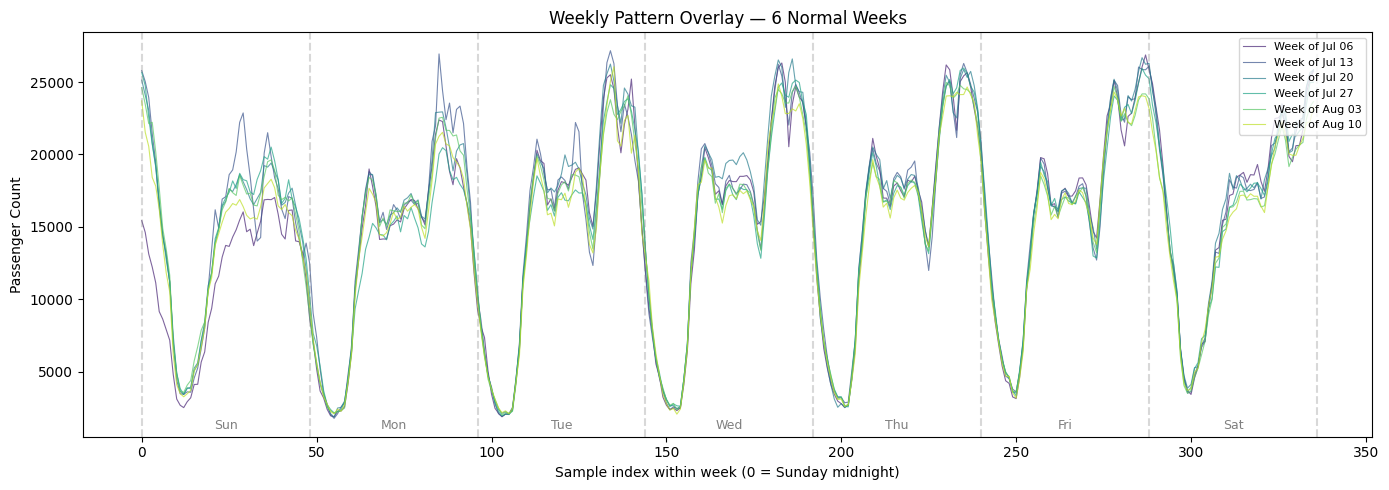

In [4]:
# Overlay weeks to show repeating pattern
# Use the first 6 weeks of data (all normal) starting from a Sunday alignment
offset_start = df["timestamp"].min() + pd.Timedelta(days=5)  # align to Sunday
df_aligned = df[df["timestamp"] >= offset_start].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 5))
day_labels = ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]
colors = plt.cm.viridis(np.linspace(0.1, 0.9, 6))

for w in range(6):
    start = w * SAMPLES_PER_WEEK
    end = start + SAMPLES_PER_WEEK
    if end > len(df_aligned):
        break
    week_vals = df_aligned["value"].iloc[start:end].values
    week_start_date = df_aligned["timestamp"].iloc[start].strftime("%b %d")
    ax.plot(range(SAMPLES_PER_WEEK), week_vals, linewidth=0.8, alpha=0.7,
            color=colors[w], label=f"Week of {week_start_date}")

# Add day boundary markers and labels
for d in range(8):
    x = d * SAMPLES_PER_DAY
    if x <= SAMPLES_PER_WEEK:
        ax.axvline(x, color="gray", alpha=0.3, linestyle="--")
        if d < 7:
            ax.text(x + SAMPLES_PER_DAY // 2, 0.02, day_labels[d],
                    ha="center", fontsize=9, color="gray",
                    transform=ax.get_xaxis_transform())

ax.set_title("Weekly Pattern Overlay — 6 Normal Weeks")
ax.set_xlabel("Sample index within week (0 = Sunday midnight)")
ax.set_ylabel("Passenger Count")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

The pattern is remarkably consistent: weekday peaks around 20,000+, weekend dips to ~12,000, and nightly lows near 2,000-5,000. This regularity is exactly what an autoencoder can learn to reconstruct.

### Autocorrelation

**Autocorrelation** measures how similar a signal is to a delayed (shifted) copy of itself. If we slide the time series forward by some number of samples (the *lag*) and compare it to the original, a high autocorrelation means the shifted version still looks a lot like the original.

For periodic data like taxi demand:
- At **lag 48** (one day), the pattern repeats — morning rush, evening rush, nightly lull — so autocorrelation is high.
- At **lag 336** (one week), the full weekly cycle repeats, so autocorrelation is high again.

Peaks in the autocorrelation plot confirm the dominant periodicities in the data. This is what justifies our choice to use **weekly windows (336 samples)** as the unit of analysis — one week captures a complete cycle of the repeating pattern.

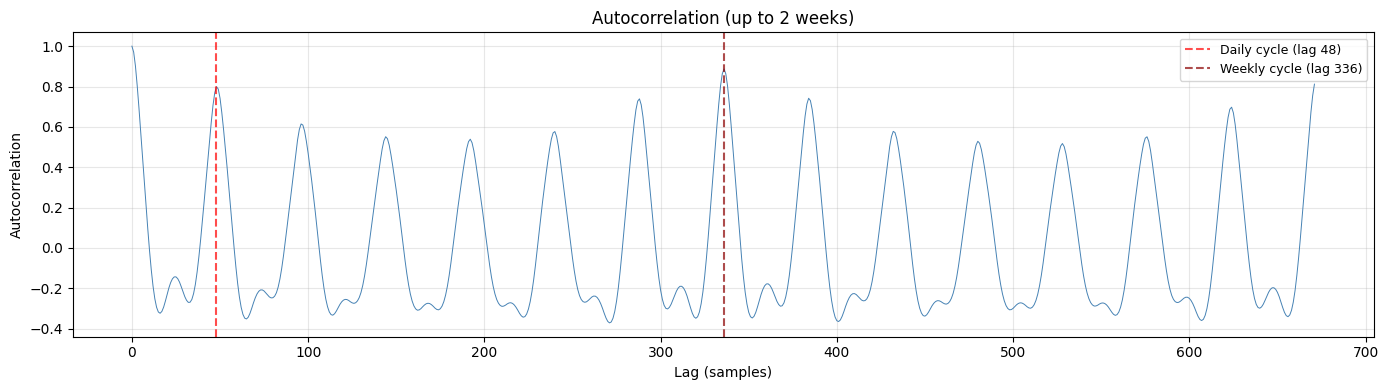

Autocorrelation at daily lag  (48): 0.799
Autocorrelation at weekly lag (336): 0.887


In [5]:
# Autocorrelation up to 2 weeks
max_lag = SAMPLES_PER_WEEK * 2
values = df["value"].values
mean = values.mean()
var = np.sum((values - mean) ** 2)
acf = np.array([np.sum((values[:len(values)-lag] - mean) * (values[lag:] - mean)) / var
                for lag in range(max_lag)])

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(acf, linewidth=0.7, color="steelblue")
ax.axvline(SAMPLES_PER_DAY, color="red", linestyle="--", alpha=0.7, label=f"Daily cycle (lag {SAMPLES_PER_DAY})")
ax.axvline(SAMPLES_PER_WEEK, color="darkred", linestyle="--", alpha=0.7, label=f"Weekly cycle (lag {SAMPLES_PER_WEEK})")
ax.set_title("Autocorrelation (up to 2 weeks)")
ax.set_xlabel("Lag (samples)")
ax.set_ylabel("Autocorrelation")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Autocorrelation at daily lag  ({SAMPLES_PER_DAY}): {acf[SAMPLES_PER_DAY]:.3f}")
print(f"Autocorrelation at weekly lag ({SAMPLES_PER_WEEK}): {acf[SAMPLES_PER_WEEK]:.3f}")

The clear peaks at lag 48 (daily) and lag 336 (weekly) confirm the dual periodicity. The weekly peak is especially strong, which is why we segment data into **weekly windows** — one week captures a full cycle of the repeating pattern.

## 4. Why Simple Thresholds Fail

A natural first approach is to flag any value above (or below) a fixed threshold as anomalous. But the anomalies in this dataset are **contextual** -- they are only anomalous *relative to when they occur*, not in absolute terms.

Consider the NYC Marathon (Nov 1-2, a weekend): taxi demand spikes because of the event, but the absolute values may be comparable to a normal weekday peak. A fixed threshold either:
- Is set too high and **misses** contextual anomalies
- Is set too low and generates **false positives** on every weekday peak

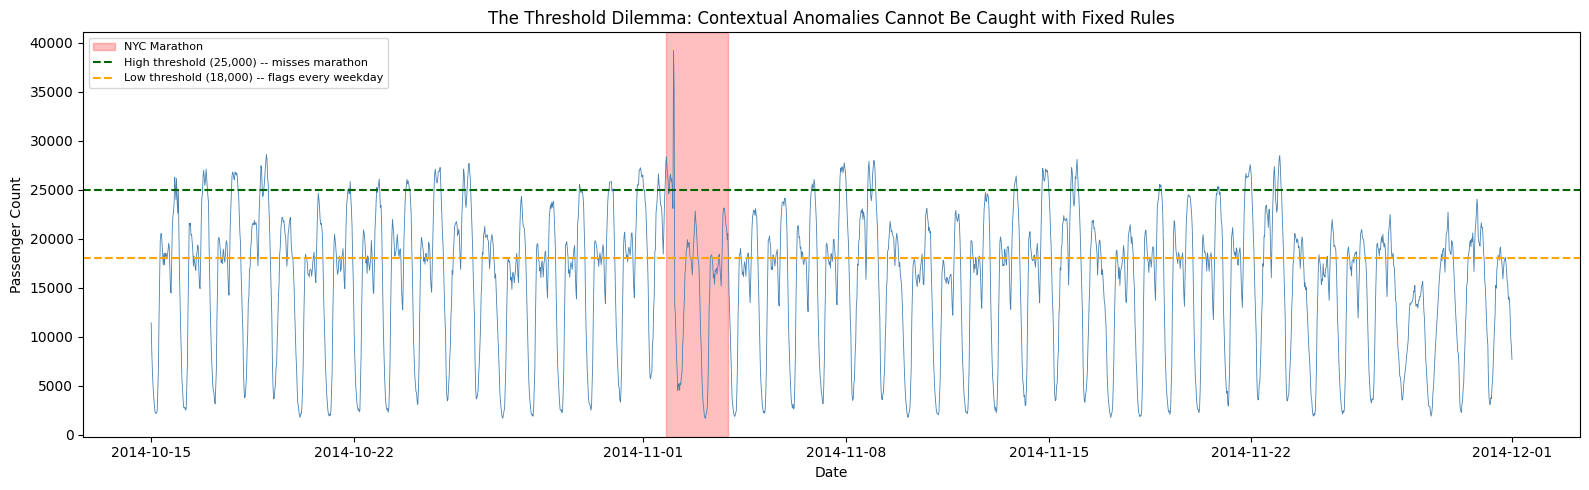

In [6]:
# Demonstrate the threshold dilemma
fig, ax = plt.subplots(figsize=(16, 5))

# Plot 2 months around the marathon
mask = (df["timestamp"] >= "2014-10-15") & (df["timestamp"] <= "2014-12-01")
subset = df[mask]

ax.plot(subset["timestamp"], subset["value"], linewidth=0.6, color="steelblue")

# Marathon anomaly window
ax.axvspan(pd.Timestamp("2014-11-01 19:00:00"), pd.Timestamp("2014-11-03 22:30:00"),
           alpha=0.25, color="red", label="NYC Marathon")

# Show two candidate thresholds
high_thresh = 25000
low_thresh = 18000

ax.axhline(high_thresh, color="darkgreen", linestyle="--", linewidth=1.5,
           label=f"High threshold ({high_thresh:,}) -- misses marathon")
ax.axhline(low_thresh, color="orange", linestyle="--", linewidth=1.5,
           label=f"Low threshold ({low_thresh:,}) -- flags every weekday")

ax.set_title("The Threshold Dilemma: Contextual Anomalies Cannot Be Caught with Fixed Rules")
ax.set_xlabel("Date")
ax.set_ylabel("Passenger Count")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

The marathon anomaly occurs on a **weekend** when demand is normally low (~12,000), but the spike reaches ~20,000. A threshold at 25,000 misses it entirely. A threshold at 18,000 catches it but also flags every normal weekday peak as anomalous.

The core problem: **what is "normal" depends on the time of week.** We need a model that understands the temporal context.

### Can a smarter baseline do better?

Fixed thresholds are clearly too naive. What about a proper time series forecasting method?

**Simple Exponential Smoothing (SES)** is a standard baseline for time series. It predicts each future value as a weighted average of all past observations, with exponentially decaying weights — recent values matter more than old ones. If the forecast is close to reality, the week is normal; if the actual values diverge from the forecast, something unusual happened.

This is a step up from a flat threshold because SES adapts to the recent level of the data. Let's see if it can separate anomalies from normal weeks.

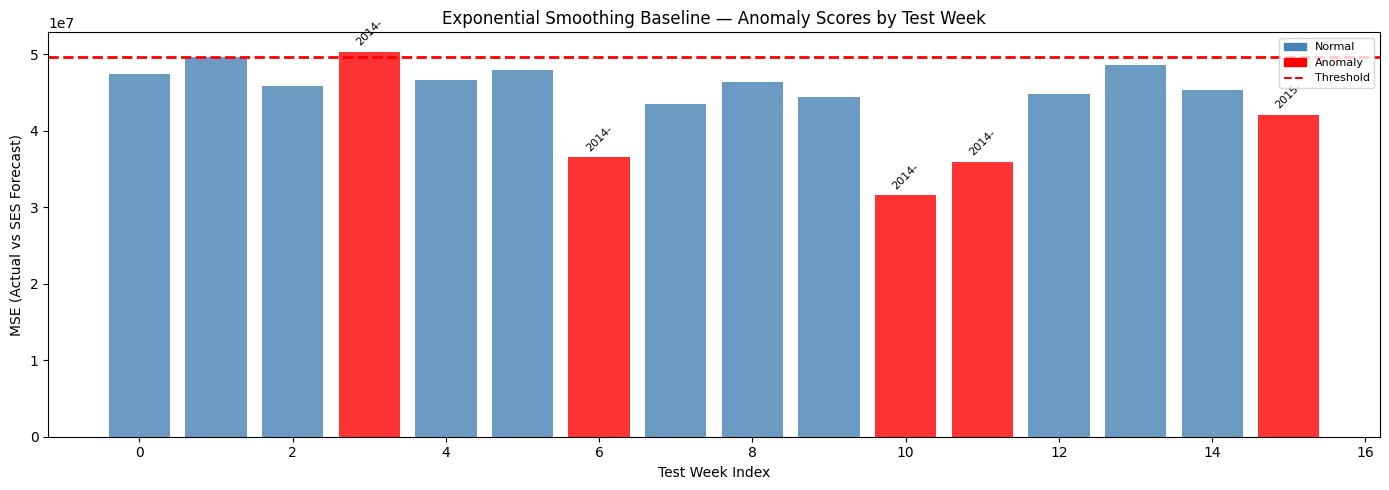

SES Baseline Results (best possible threshold):
  Accuracy: 12/16 (75%)
  TP=1  FP=0  FN=4

Week              SES Score  Predicted     Actual  Match
--------------------------------------------------------
2014-10-12       47,413,762     normal     normal      Y
2014-10-19       49,639,673     normal     normal      Y
2014-10-26       45,879,481     normal     normal      Y
2014-11-02       50,354,755    ANOMALY    ANOMALY      Y
2014-11-09       46,622,967     normal     normal      Y
2014-11-16       47,982,499     normal     normal      Y
2014-11-23       36,575,792     normal    ANOMALY      N
2014-11-30       43,529,594     normal     normal      Y
2014-12-07       46,320,915     normal     normal      Y
2014-12-14       44,436,440     normal     normal      Y
2014-12-21       31,553,074     normal    ANOMALY      N
2014-12-28       35,976,251     normal    ANOMALY      N
2015-01-04       44,806,026     normal     normal      Y
2015-01-11       48,620,173     normal     normal    

In [7]:
from src.preprocess import segment_into_weeks, create_splits, PreprocessorConfig

# Segment data and create splits (same as used for LSTM training)
weekly_data, week_info = segment_into_weeks(df)
config = PreprocessorConfig()
splits, split_indices = create_splits(weekly_data, week_info, config)

train_indices = split_indices["train"]
test_indices = split_indices["test"]
test_info = [week_info[i] for i in test_indices]

# Build a continuous series: all weeks in chronological order
all_ordered_indices = train_indices + split_indices["val"] + split_indices["threshold_val"] + test_indices
all_values = np.concatenate([weekly_data[i] for i in all_ordered_indices])

# Apply Simple Exponential Smoothing (span=48 = 1-day half-life)
all_series = pd.Series(all_values)
ewm_smoothed = all_series.ewm(span=SAMPLES_PER_DAY).mean().values

# SES "forecast" for each point = the smoothed value at the PREVIOUS timestep
# (what you'd predict before seeing the actual value)
ses_forecast = np.roll(ewm_smoothed, 1)
ses_forecast[0] = all_values[0]

# Score each test week: MSE between actual values and SES forecast
n_pre_test = (len(train_indices) + len(split_indices["val"]) + len(split_indices["threshold_val"])) * SAMPLES_PER_WEEK

ses_scores = []
for w in range(len(test_indices)):
    start = n_pre_test + w * SAMPLES_PER_WEEK
    end = start + SAMPLES_PER_WEEK
    mse = np.mean((all_values[start:end] - ses_forecast[start:end]) ** 2)
    ses_scores.append(mse)
ses_scores = np.array(ses_scores)

# Find the best possible threshold for SES
best_acc, best_thresh = 0, 0
for t in np.linspace(ses_scores.min(), ses_scores.max(), 500):
    correct = sum(1 for s, info in zip(ses_scores > t, test_info) if s == info["is_anomaly"])
    if correct > best_acc:
        best_acc = correct
        best_thresh = t

ses_preds = ses_scores > best_thresh

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
colors = ["red" if info["is_anomaly"] else "steelblue" for info in test_info]
ax.bar(range(len(ses_scores)), ses_scores, color=colors, alpha=0.8)
ax.axhline(best_thresh, color="red", ls="--", lw=2, label=f"Best threshold")

for i, info in enumerate(test_info):
    if info["is_anomaly"]:
        ax.text(i, ses_scores[i] + 5e5, info["year_week"][:5],
                ha="center", va="bottom", fontsize=8, rotation=45)

ax.set_title("Exponential Smoothing Baseline — Anomaly Scores by Test Week")
ax.set_xlabel("Test Week Index")
ax.set_ylabel("MSE (Actual vs SES Forecast)")

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="steelblue", label="Normal"), Patch(color="red", label="Anomaly"),
    plt.Line2D([0], [0], color="red", ls="--", label="Threshold"),
], loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

# Results table
tp = sum(1 for p, info in zip(ses_preds, test_info) if p and info["is_anomaly"])
fp = sum(1 for p, info in zip(ses_preds, test_info) if p and not info["is_anomaly"])
fn = sum(1 for p, info in zip(ses_preds, test_info) if not p and info["is_anomaly"])

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0

print(f"SES Baseline Results (best possible threshold):")
print(f"  Accuracy:  {best_acc}/{len(test_info)} ({100*best_acc/len(test_info):.0f}%)")
print(f"  Precision: {precision:.0%}")
print(f"  Recall:    {recall:.0%}")
print(f"  TP={tp}  FP={fp}  FN={fn}")
print(f"\n{'Week':<12} {'SES Score':>14} {'Predicted':>10} {'Actual':>10} {'Match':>6}")
print("-" * 56)
for score, pred, info in zip(ses_scores, ses_preds, test_info):
    pred_str = "ANOMALY" if pred else "normal"
    actual_str = "ANOMALY" if info["is_anomaly"] else "normal"
    match = "Y" if (pred == info["is_anomaly"]) else "N"
    print(f"{info['year_week']:<12} {score:>14,.0f} {pred_str:>10} {actual_str:>10} {match:>6}")

Even with the **best possible threshold** (chosen with hindsight on the test labels), exponential smoothing achieves only ~75% accuracy with **20% recall** — it catches just 1 out of 5 anomalies. The core issue: SES forecasts each point based on a weighted average of recent values, but it has **no concept of the weekly cycle**. It doesn't know that Sunday at midnight should be low and Wednesday at noon should be high. So normal weekly variation produces forecast errors that overlap heavily with anomaly-driven errors.

This is the gap that motivates the LSTM autoencoder: we need a model that learns the **full weekly temporal structure**, not just the recent trend level. In notebook 2, we'll build that model and compare it directly against this SES baseline.

## 5. Normal vs. Anomaly Weeks

Let's use `segment_into_weeks` to split the data into weekly windows and directly compare normal weeks against weeks containing anomalies.

In [8]:
# weekly_data and week_info were already computed above in the SES baseline section

print(f"Total weeks: {len(week_info)}")
print(f"Normal weeks: {sum(1 for w in week_info if not w['is_anomaly'])}")
print(f"Anomaly weeks: {sum(1 for w in week_info if w['is_anomaly'])}")
print()
for i, w in enumerate(week_info):
    status = "ANOMALY" if w["is_anomaly"] else "normal"
    print(f"  Week {i:2d}: {w['year_week']}  [{status}]  mean={w['mean_value']:.0f}")

Total weeks: 30
Normal weeks: 25
Anomaly weeks: 5

  Week  0: 2014-07-06  [normal]  mean=14874
  Week  1: 2014-07-13  [normal]  mean=15567
  Week  2: 2014-07-20  [normal]  mean=15655
  Week  3: 2014-07-27  [normal]  mean=15107
  Week  4: 2014-08-03  [normal]  mean=15081
  Week  5: 2014-08-10  [normal]  mean=14723
  Week  6: 2014-08-17  [normal]  mean=14442
  Week  7: 2014-08-24  [normal]  mean=13857
  Week  8: 2014-08-31  [normal]  mean=15127
  Week  9: 2014-09-07  [normal]  mean=16356
  Week 10: 2014-09-14  [normal]  mean=16075
  Week 11: 2014-09-21  [normal]  mean=14938
  Week 12: 2014-09-28  [normal]  mean=15700
  Week 13: 2014-10-05  [normal]  mean=15994
  Week 14: 2014-10-12  [normal]  mean=16114
  Week 15: 2014-10-19  [normal]  mean=16288
  Week 16: 2014-10-26  [normal]  mean=16394
  Week 17: 2014-11-02  [ANOMALY]  mean=15995
  Week 18: 2014-11-09  [normal]  mean=15755
  Week 19: 2014-11-16  [normal]  mean=16031
  Week 20: 2014-11-23  [ANOMALY]  mean=13778
  Week 21: 2014-11-30  

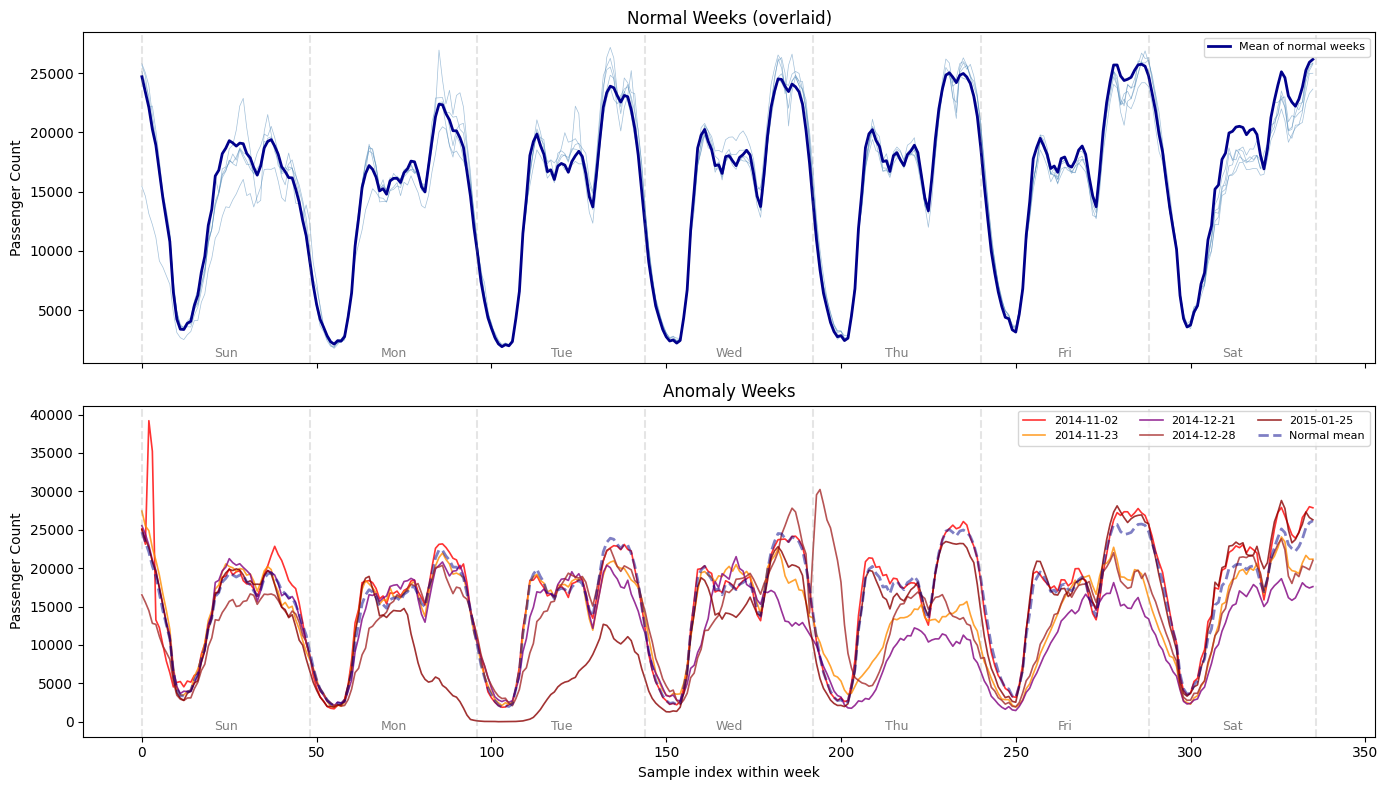

In [9]:
# Compare normal weeks vs anomaly weeks side by side
normal_indices = [i for i, w in enumerate(week_info) if not w["is_anomaly"]]
anomaly_indices = [i for i, w in enumerate(week_info) if w["is_anomaly"]]

day_labels = ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Normal weeks
ax = axes[0]
for idx in normal_indices[:5]:  # show first 5 normal weeks
    ax.plot(range(SAMPLES_PER_WEEK), weekly_data[idx], linewidth=0.5, alpha=0.5, color="steelblue")
ax.plot(range(SAMPLES_PER_WEEK), weekly_data[normal_indices].mean(axis=0),
        linewidth=2, color="darkblue", label="Mean of normal weeks")
for d in range(8):
    x = d * SAMPLES_PER_DAY
    if x <= SAMPLES_PER_WEEK:
        ax.axvline(x, color="gray", alpha=0.2, linestyle="--")
        if d < 7:
            ax.text(x + SAMPLES_PER_DAY // 2, 0.02, day_labels[d],
                    ha="center", fontsize=9, color="gray",
                    transform=ax.get_xaxis_transform())
ax.set_title("Normal Weeks (overlaid)")
ax.set_ylabel("Passenger Count")
ax.legend(fontsize=8)

# Anomaly weeks
ax = axes[1]
colors_anom = ["red", "darkorange", "purple", "brown", "darkred"]
for j, idx in enumerate(anomaly_indices):
    label = week_info[idx]["year_week"]
    ax.plot(range(SAMPLES_PER_WEEK), weekly_data[idx], linewidth=1.2,
            color=colors_anom[j % len(colors_anom)], alpha=0.8, label=label)
# Also show normal mean for reference
ax.plot(range(SAMPLES_PER_WEEK), weekly_data[normal_indices].mean(axis=0),
        linewidth=2, color="darkblue", linestyle="--", alpha=0.5, label="Normal mean")
for d in range(8):
    x = d * SAMPLES_PER_DAY
    if x <= SAMPLES_PER_WEEK:
        ax.axvline(x, color="gray", alpha=0.2, linestyle="--")
        if d < 7:
            ax.text(x + SAMPLES_PER_DAY // 2, 0.02, day_labels[d],
                    ha="center", fontsize=9, color="gray",
                    transform=ax.get_xaxis_transform())
ax.set_title("Anomaly Weeks")
ax.set_xlabel("Sample index within week")
ax.set_ylabel("Passenger Count")
ax.legend(fontsize=8, ncol=3)

plt.tight_layout()
plt.show()

The contrast is striking:
- **Normal weeks** follow a tight, predictable pattern.
- **Anomaly weeks** deviate in diverse ways -- the marathon causes a weekend spike, Thanksgiving suppresses midweek demand, Christmas and New Year's flatten the weekday pattern, and the blizzard drops demand to near zero.

These are *shape* anomalies, not just value anomalies. An autoencoder that learns to reconstruct the normal weekly *shape* will naturally produce high reconstruction error on these distorted patterns.

## 6. Why Reconstruction-Based Detection Works

Here is the key insight behind the LSTM autoencoder approach:

1. **Train** the autoencoder only on **normal** weekly patterns. It learns to compress and reconstruct the typical Sun-Sat demand cycle.

2. At **inference**, feed in a new week. If it is normal, the autoencoder reconstructs it accurately (low error). If it is anomalous, the autoencoder *cannot* reproduce the unusual shape because it has never seen anything like it -- the reconstruction reverts toward the "average" normal pattern.

3. **Reconstruction error** (the gap between input and output) becomes the anomaly score. High error = likely anomaly.

This approach is inherently context-aware: it does not compare against a fixed threshold on raw values, but against what the model *expects* for each position in the weekly cycle.

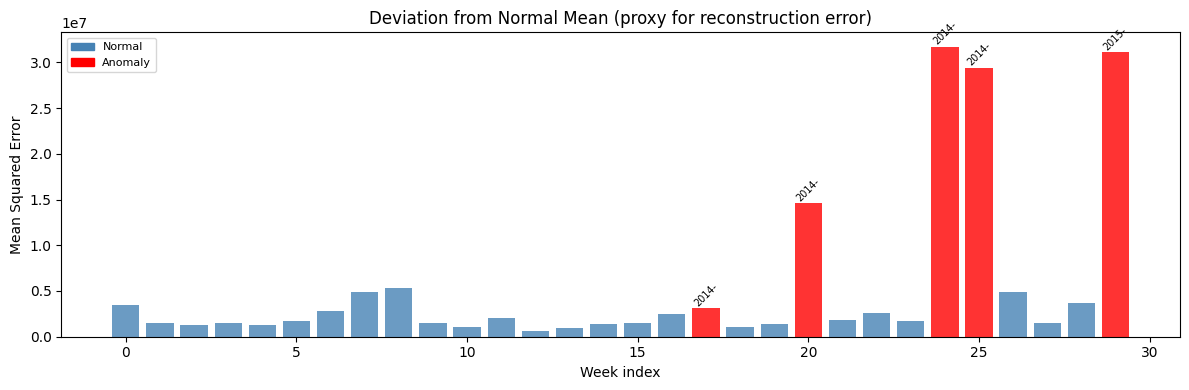

In [10]:
# Simulate what reconstruction error would look like
# A simple proxy: distance of each week from the normal mean pattern
normal_mean = weekly_data[normal_indices].mean(axis=0)

errors = []
for i in range(len(weekly_data)):
    mse = np.mean((weekly_data[i] - normal_mean) ** 2)
    errors.append(mse)

fig, ax = plt.subplots(figsize=(12, 4))
colors_bar = ["red" if week_info[i]["is_anomaly"] else "steelblue" for i in range(len(week_info))]
bars = ax.bar(range(len(errors)), errors, color=colors_bar, alpha=0.8)

# Label anomaly bars
for i, w in enumerate(week_info):
    if w["is_anomaly"]:
        ax.text(i, errors[i], w["year_week"][:5], ha="center", va="bottom", fontsize=7, rotation=45)

ax.set_title("Deviation from Normal Mean (proxy for reconstruction error)")
ax.set_xlabel("Week index")
ax.set_ylabel("Mean Squared Error")

# Custom legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="steelblue", label="Normal"), Patch(color="red", label="Anomaly")],
          loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

Even with this crude proxy (distance from the mean), anomaly weeks clearly stand out with higher "reconstruction error." A trained LSTM autoencoder will sharpen this separation further because it learns the *temporal dynamics* (not just the mean) of the weekly pattern.

## 7. Weekly Segmentation Strategy

The raw data starts on **July 1, 2014 (Tuesday)**. To get clean Sunday-to-Saturday weeks, we apply an **offset of 5 days**, starting segmentation from **July 6, 2014 (Sunday)**.

This yields **29 complete weeks**, of which:
- ~22 are normal (used for training, validation, and threshold calibration)
- ~7 contain anomalies (reserved for testing)

The data split follows the paper's methodology:
- **Train** (9 normal weeks): learn to reconstruct normal patterns
- **Validation** (3 normal weeks): early stopping during training
- **Threshold calibration** (2 normal weeks): fit the error distribution for threshold selection
- **Test** (remaining ~15 weeks): evaluate anomaly detection performance

Offset: 5 days (start on Sunday)
Total complete weeks: 30

  train          :  9 weeks  (anomaly: 0)
  val            :  3 weeks  (anomaly: 0)
  threshold_val  :  2 weeks  (anomaly: 0)
  test           : 16 weeks  (anomaly: 5)


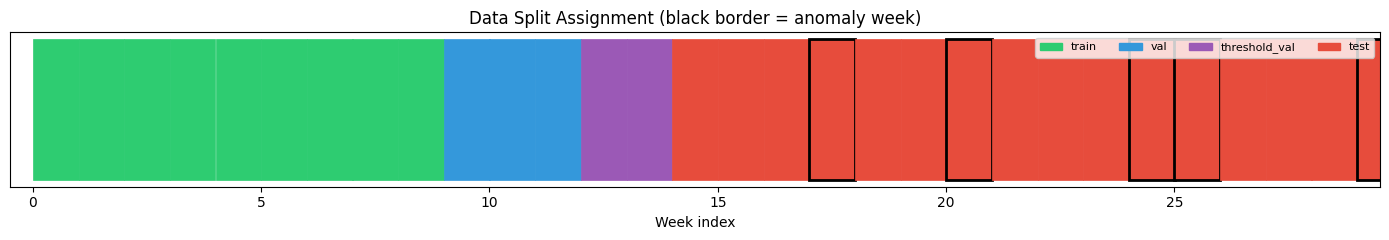

In [11]:
from matplotlib.patches import Patch

# splits and split_indices were already computed above in the SES baseline section

print(f"Offset: {config.offset_days} days (start on Sunday)")
print(f"Total complete weeks: {len(week_info)}")
print()
for name, indices in split_indices.items():
    anomaly_count = sum(1 for i in indices if week_info[i]["is_anomaly"])
    print(f"  {name:15s}: {len(indices):2d} weeks  (anomaly: {anomaly_count})")

# Visualize the split assignment
fig, ax = plt.subplots(figsize=(14, 2.5))
split_colors = {"train": "#2ecc71", "val": "#3498db", "threshold_val": "#9b59b6", "test": "#e74c3c"}

for name, indices in split_indices.items():
    for idx in indices:
        facecolor = split_colors[name]
        edgecolor = "black" if week_info[idx]["is_anomaly"] else facecolor
        linewidth = 2 if week_info[idx]["is_anomaly"] else 0.5
        ax.barh(0, 1, left=idx, color=facecolor, edgecolor=edgecolor, linewidth=linewidth)

ax.set_xlim(-0.5, len(week_info) - 0.5)
ax.set_yticks([])
ax.set_xlabel("Week index")
ax.set_title("Data Split Assignment (black border = anomaly week)")

legend_patches = [Patch(color=c, label=n) for n, c in split_colors.items()]
ax.legend(handles=legend_patches, loc="upper right", fontsize=8, ncol=4)

plt.tight_layout()
plt.show()

## Summary

Key takeaways from this exploration:

1. **Strong periodicity**: Taxi demand follows a highly regular daily and weekly cycle, making it learnable.
2. **Contextual anomalies**: The known anomalies are deviations from the expected *pattern*, not just extreme values. Simple thresholds cannot detect them reliably.
3. **Exponential smoothing fails**: Even a proper time series baseline (SES) achieves only ~75% accuracy because it lacks awareness of the weekly cycle structure.
4. **Reconstruction-based detection**: By training an autoencoder exclusively on normal weekly patterns, we get a model that naturally assigns high reconstruction error to anomalous weeks.
5. **Clean segmentation**: The offset alignment gives us 29 complete weeks with a clear split into training (normal only) and testing (includes all anomaly types).

Next: **Model Design** — building the LSTM Encoder-Decoder and comparing it against the SES baseline.